# Pandas Explode

In [2]:
# get the counts of the skills inside the lists of the "job_skills" collumn

import pandas as pd

data = {
    "job_title_short": ["Data Analyst","Data Scientist","Data Engineer"],
    "job_skills": [["Excel", "sql", "python"], ["python","r"], ["aws", "python", "airflow"]]
}

df_skills = pd.DataFrame(data)
df_skills

,job_title_short,job_skills
0,Data Analyst,"[Excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


In [3]:
for row in df_skills.itertuples():
  for skill in row.job_skills:
    df_skills[skill] = df_skills["job_skills"].apply(lambda x: skill in x)
    df_skills[skill] = df_skills[skill].astype(int)

df_skills.loc["Total"] = df_skills.sum()

df_skills

,job_title_short,job_skills,Excel,sql,python,r,aws,airflow
0,Data Analyst,"[Excel, sql, python]",1,1,1,0,0,0
1,Data Scientist,"[python, r]",0,0,1,1,0,0
2,Data Engineer,"[aws, python, airflow]",0,0,1,0,1,1
Total,Data AnalystData ScientistData Engineer,"[Excel, sql, python, python, r, aws, python, a...",1,1,3,1,1,1


En lugar de eso podemos usar explode:

In [9]:
data = {
    "job_title_short": ["Data Analyst","Data Scientist","Data Engineer"],
    "job_skills": [["Excel", "sql", "python"], ["python","r"], ["aws", "python", "airflow"]]
}
df_skills = pd.DataFrame(data)

df_skills.explode("job_skills")

,job_title_short,job_skills
0,Data Analyst,Excel
0,Data Analyst,sql
0,Data Analyst,python
1,Data Scientist,python
1,Data Scientist,r
2,Data Engineer,aws
2,Data Engineer,python
2,Data Engineer,airflow


In [10]:
df_skills.explode("job_skills").value_counts("job_skills")

,count
job_skills,
python,3
Excel,1
airflow,1
aws,1
r,1
sql,1


<Axes: xlabel='job_skills'>

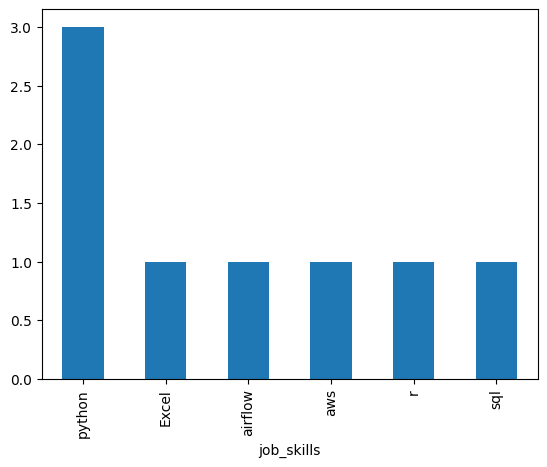

In [11]:
df_skills.explode("job_skills").value_counts("job_skills").plot(kind="bar")

# Aplicado

In [12]:
from datasets import load_dataset
import pandas as pd
import ast

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df.sort_values(by="job_posted_date", inplace=True)

df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 785741 entries, 108804 to 90102
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   float

In [17]:
df_exploded = df.explode("job_skills")
df_exploded['job_skills'].value_counts().head(10)


,count
job_skills,
sql,384849
python,380909
aws,145381
azure,132527
r,130892
tableau,127213
excel,127018
spark,114609
power bi,98147


<Axes: xlabel='job_skills'>

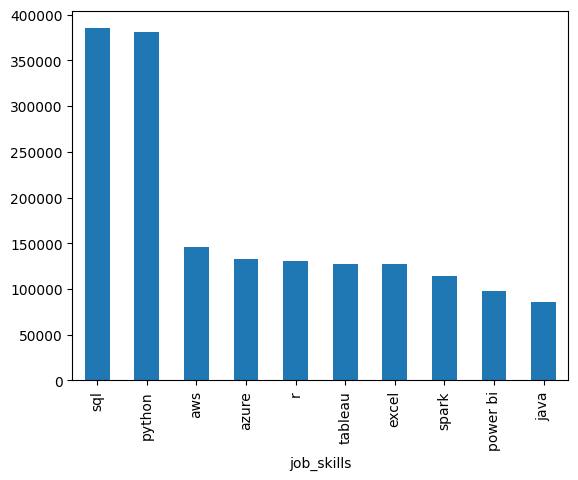

In [18]:
df_exploded['job_skills'].value_counts().head(10).plot(kind="bar")

In [20]:
skills_count = df_exploded.groupby(["job_skills","job_title_short"]).size()
skills_count

job_skills  job_title_short          
airflow     Business Analyst               318
            Cloud Engineer                 260
            Data Analyst                  2002
            Data Engineer                25505
            Data Scientist                3915
                                         ...  
zoom        Machine Learning Engineer       46
            Senior Data Analyst             86
            Senior Data Engineer           122
            Senior Data Scientist           79
            Software Engineer              229
Length: 2256, dtype: int64

In [21]:
type(skills_count)

pandas.core.series.Series

In [29]:
df_skills_count = (

    skills_count.reset_index(name="skill_count")
    .sort_values(by="skill_count", ascending=False)

    )
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


<Axes: xlabel='job_skills'>

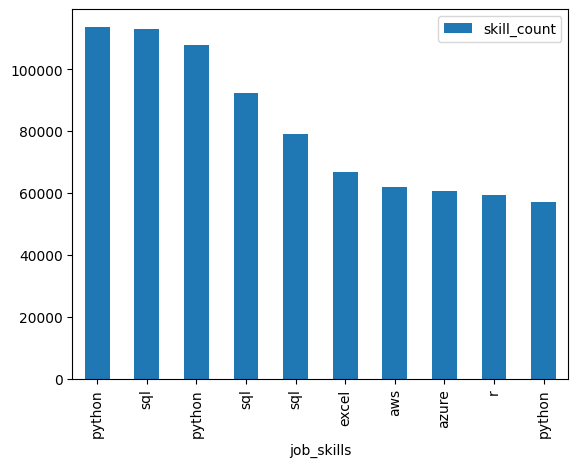

In [31]:
df_skills_count.head(10).plot("job_skills","skill_count", kind="bar")

In [32]:
job_title = "Data Analyst"
top_skills = 10

df_skill_final = df_skills_count[df_skills_count["job_title_short"] == job_title].head(top_skills)

df_skill_final

,job_skills,job_title_short,skill_count
1821,sql,Data Analyst,92428
558,excel,Data Analyst,66860
1478,python,Data Analyst,57190
1941,tableau,Data Analyst,46455
1410,power bi,Data Analyst,39380
1516,r,Data Analyst,29996
1635,sas,Data Analyst,27998
1429,powerpoint,Data Analyst,13822
2198,word,Data Analyst,13562
1625,sap,Data Analyst,11280


Text(0, 0.5, 'Skills')

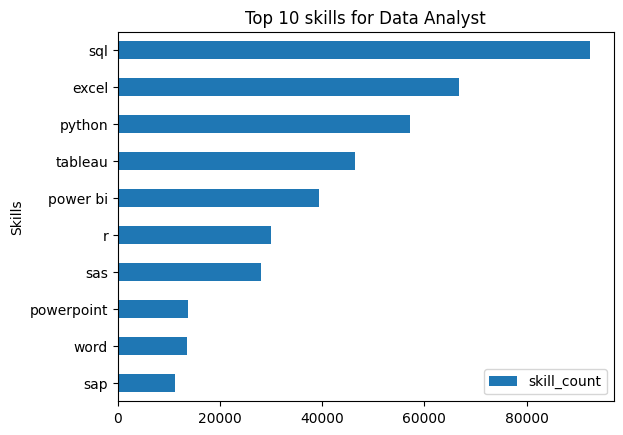

In [41]:
import matplotlib.pyplot as plt
df_skill_final.plot( "job_skills", "skill_count", kind="barh")
plt.gca().invert_yaxis()
plt.title(f"Top {top_skills} skills for {job_title}")
plt.ylabel("Skills")